In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image
from io import BytesIO

<h1>Q1</h1>

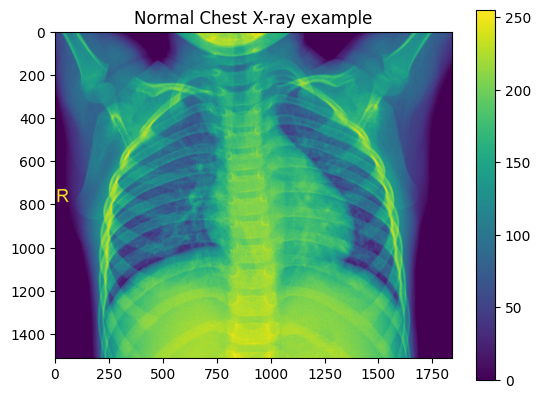

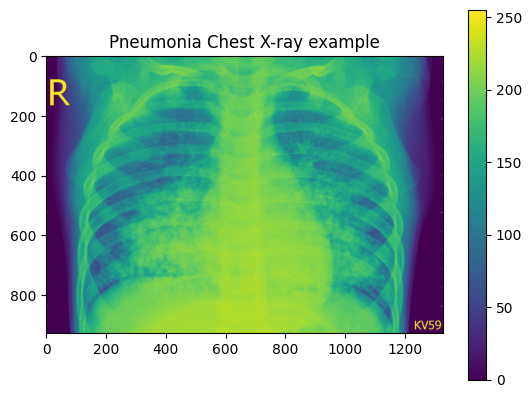

In [4]:
# Load the data
train_url = 'ml4h_data/p2/part2/archive/chest_xray/train'
test_url = 'ml4h_data/p2/part2/archive/chest_xray/test'
val_url = 'ml4h_data/p2/part2/archive/chest_xray/val'

normal_url = '/NORMAL'
pneumonia_url = '/PNEUMONIA'

# Plot an example image
img_url = os.listdir(train_url + normal_url)[0]
img = Image.open(train_url + normal_url + '/' + img_url)
plt.imshow(img)
plt.title('Normal Chest X-ray example')
plt.colorbar()
plt.show()

img_url = os.listdir(train_url + pneumonia_url)[0]
img = Image.open(train_url + pneumonia_url + '/' + img_url)
plt.imshow(img)
plt.title('Pneumonia Chest X-ray example')
plt.colorbar()
plt.show()

<h2>Q1.2</h2>

The visual differences are quite noticeable between normal and disease samples, as the disease samples exhibit much higher average pixel intensity in the region of the lungs. This is caused by inflammation appearing in the x rays.

<h2>Q1.3</h2>
One source of bias that could influence the model is the uneven distribution of pneumonia and normal x rays. As we can see, half of the images are bacterial pneumonia and the other half is somewhat evenly distributed between normal and viral.

Normal: 1341, Pneumonia_Bacterial: 2530, Pneumonia_Viral: 1345


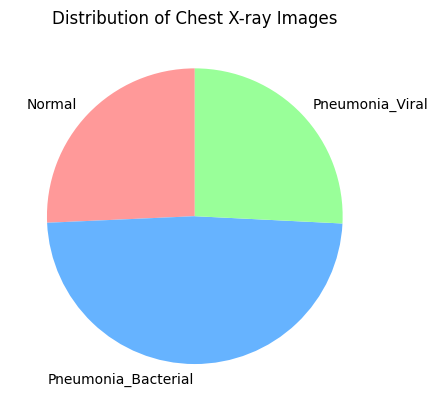

In [5]:
base_url = train_url

normal_count = len(os.listdir(base_url + normal_url))

pneumonia_files = os.listdir(base_url + pneumonia_url)
pneumonia_bacterial_count = len([f for f in pneumonia_files if 'bacteria' in f])
pneumonia_viral_count = len([f for f in pneumonia_files if 'virus' in f])

categories = ['Normal', 'Pneumonia_Bacterial', 'Pneumonia_Viral']
sizes = [normal_count, pneumonia_bacterial_count, pneumonia_viral_count]
colors = ['#FF9999', '#66B3FF', '#99FF99']

print(f"Normal: {normal_count}, Pneumonia_Bacterial: {pneumonia_bacterial_count}, Pneumonia_Viral: {pneumonia_viral_count}")

plt.pie([normal_count, pneumonia_bacterial_count, pneumonia_viral_count], labels=categories, colors=colors, startangle=90)

plt.title('Distribution of Chest X-ray Images')
plt.show()

<h2>Q1.4</h2>
For further analysis, we preprocess the images by making sure they are the same dimensions (224x224). We first downsample the images if they are too large and we add padding to make sure that the aspect ratio is maintained.

In [6]:
import cv2

(1511, 1840)


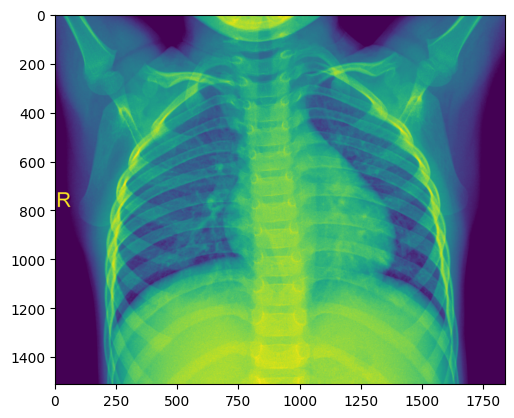

In [7]:
img_url = os.listdir(train_url + normal_url)[0]
img = cv2.imread(train_url + normal_url + '/' + img_url, cv2.IMREAD_GRAYSCALE)
print(img.shape)
plt.imshow(img)

df = pd.DataFrame(columns=['url', 'label', 'width', 'height'])

for f in os.listdir(train_url + normal_url):
    img = cv2.imread(train_url + normal_url + '/' + f)
    url = train_url + normal_url + '/' + f
    df = pd.concat([df, pd.DataFrame([{'url': url, 'label': 'normal', 'width': img.shape[0], 'height': img.shape[1]}])])

In [8]:
for f in os.listdir(train_url + pneumonia_url):
    img = cv2.imread(train_url + pneumonia_url + '/' + f)
    url = train_url + pneumonia_url + '/' + f
    df = pd.concat([df, pd.DataFrame([{'url': url, 'label': 'bacterial' if 'bacteria' in f else 'viral', 'width': img.shape[0], 'height': img.shape[1]}])])


In [9]:
df.reset_index(drop=True, inplace=True)
df

,url,label,width,height
0,ml4h_data/p2/part2/archive/chest_xray/train/NO...,normal,1511,1840
1,ml4h_data/p2/part2/archive/chest_xray/train/NO...,normal,1557,1882
2,ml4h_data/p2/part2/archive/chest_xray/train/NO...,normal,1241,1662
3,ml4h_data/p2/part2/archive/chest_xray/train/NO...,normal,1167,1558
4,ml4h_data/p2/part2/archive/chest_xray/train/NO...,normal,1136,1248
...,...,...,...,...
5211,ml4h_data/p2/part2/archive/chest_xray/train/PN...,bacterial,704,1000
5212,ml4h_data/p2/part2/archive/chest_xray/train/PN...,viral,640,1024
5213,ml4h_data/p2/part2/archive/chest_xray/train/PN...,bacterial,1528,1688
5214,ml4h_data/p2/part2/archive/chest_xray/train/PN...,bacterial,608,920


5100
ml4h_data/p2/part2/archive/chest_xray/train/PNEUMONIA/person407_virus_811.jpeg
384


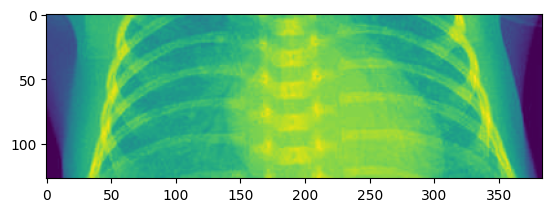

In [10]:
print(df['width'].idxmin())
print(df.iloc[df['width'].idxmin()]['url'])
img = cv2.imread(df['url'][df['width'].idxmin()], cv2.IMREAD_GRAYSCALE)
plt.imshow(img)
print(df['height'].min())


In [11]:
def resize_with_padding(img, target_size=224):
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    resized = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

    delta_w = target_size - resized.shape[1]
    delta_h = target_size - resized.shape[0]
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)

    color = 0 
    padded = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return padded

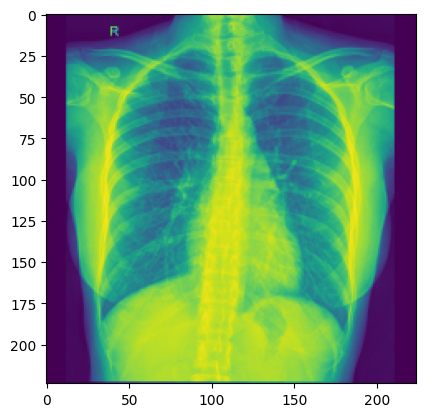

In [12]:
img = cv2.imread(df['url'][df['width'].idxmax()], cv2.IMREAD_GRAYSCALE)
# img = cv2.imread(df['url'][2], cv2.IMREAD_GRAYSCALE)
img = resize_with_padding(img)
plt.imshow(img)

In [ ]:
for idx, img_row in df.iterrows():
    img = cv2.imread(img_row['url'], cv2.IMREAD_GRAYSCALE)
    img = resize_with_padding(img)
    cv2.imwrite('ml4h_data/p2/part2/preprocessed/train/' + str(idx) + '.jpg', img)
    print(os.listdir('ml4h_data/p2/part2/'))
    break

<h2>Q2: CNN Classifier</h2>

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F